# 05 — From Predictions to Maintenance Decisions

**Goal:** choose *when to raise an alarm* based on what errors cost, not on F1.

F1 treats a missed failure and a false alarm as equally bad. In maintenance they are not: a missed
failure means an unplanned breakdown (downtime, scrap, possibly a damaged spindle), while a false alarm
means an unnecessary inspection. This notebook:

1. defines a simple cost model
2. compares alarm policies by expected cost, with honest cross-validated threshold selection
3. checks how the best policy changes when failures are cheaper or more expensive
4. calibrates the probabilities, so the demo app (M7) can show meaningful failure risks

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss

from pdm.config import FIGURES_DIR, PROJECT_ROOT
from pdm.cost import RULE_SCORE, cost_curve, cv_policy_cost, policy_cost, tool_change_score
from pdm.data import FEATURES, TARGET, load_data
from pdm.evaluate import make_cv, oof_proba
from pdm.models import hybrid_model, make_pipeline
from pdm.rules import RulesThenModel, rule_flags

sns.set_theme(style="whitegrid", context="notebook")
REPORTS_DIR = PROJECT_ROOT / "reports"
POLICY_COLORS = {
    "ML, raw features (HGB)": "#8d99ae",
    "ML + physics (HGB)": "#4c72b0",
    "Rules only": "#dd8452",
    "Hybrid (calibrated)": "#c44e52",
    "Rules + tool change": "#2a9d8f",
}


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"05_{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df = load_data()
X, y = df[FEATURES], df[TARGET]
splits = list(make_cv().split(X, y))

# Out-of-fold probabilities from M4 (same folds)
oof = pd.read_csv(REPORTS_DIR / "04_comparison_oof.csv")
scores = {
    "ML, raw features (HGB)": oof["ML, raw features (HGB)"].to_numpy(),
    "ML + physics (HGB)": oof["ML + physics (HGB)"].to_numpy(),
    "Rules only": oof["Rules only"].to_numpy(),
    "Hybrid (calibrated)": oof_proba(hybrid_model(calibrated=True), X, y, make_cv()),
    "Rules + tool change": tool_change_score(X),
}
print(f"Processes: {len(y):,} | Failures: {y.sum()}")

Processes: 10,000 | Failures: 339


## 1. Cost model

All costs are measured in units of **one inspection**:

| Event | Cost |
|---|---|
| Alarm (inspection, and repair or tool change if needed) | 1 |
| Missed failure (unplanned breakdown) | R |
| No alarm, no failure | 0 |

**Total cost = alarms + R × missed failures.** The repair itself is needed either way, so only the
*difference* between planned and unplanned handling counts.

The cost ratio **R** depends on the plant. We use **R = 10** as the default: a breakdown on a
milling machine (downtime, scrapped part, emergency repair) easily costs ten times a planned stop.
Section 4 shows how the recommendation changes for R between 2 and 100.

**The five policies compared:**

| Policy | Alarm when… |
|---|---|
| ML, raw features | gradient boosting probability ≥ threshold (M2 baseline) |
| ML + physics | same, with physics features (M4) |
| Rules only | any physics rule fires (M4) |
| Hybrid (calibrated) | a rule fires, or the calibrated ML probability ≥ threshold (see section 6) |
| **Rules + tool change** | a rule fires, or the tool has been used for ≥ W minutes |

The last policy is new. M4 showed that tool wear failures happen at a random moment between about
200 and 240 minutes, and that nothing in the sensors predicts the exact moment. Classic reliability
engineering answers this with **age-based replacement**: change the tool before it reaches the risky
age. Its threshold W is chosen from the costs, just like a probability threshold.

**Reference points:** with no predictive maintenance at all, every failure is a breakdown, which
costs 339 × R. Inspecting every process costs 10,000.

## 2. Cost curves at R = 10

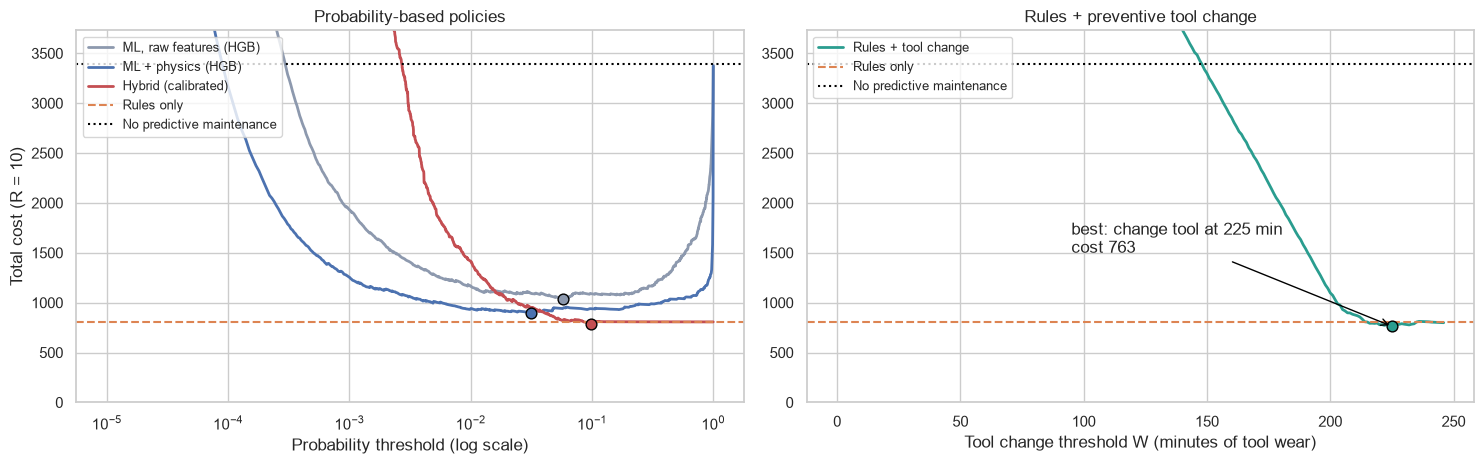

In [3]:
R = 10
never = y.sum() * R

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
for name in ["ML, raw features (HGB)", "ML + physics (HGB)", "Hybrid (calibrated)"]:
    curve = cost_curve(y, scores[name], R)
    curve = curve[np.isfinite(curve["threshold"]) & (curve["threshold"] > 0)]
    ax.plot(curve["threshold"], curve["cost"], color=POLICY_COLORS[name], lw=2, label=name)
    best = curve.loc[curve["cost"].idxmin()]
    ax.scatter(
        best["threshold"],
        best["cost"],
        color=POLICY_COLORS[name],
        s=60,
        zorder=3,
        edgecolor="black",
    )
rules_cost = cost_curve(y, scores["Rules only"], R)["cost"].min()
ax.axhline(rules_cost, color=POLICY_COLORS["Rules only"], ls="--", label="Rules only")
ax.axhline(never, color="black", ls=":", label="No predictive maintenance")
ax.set_xscale("log")
ax.set_ylim(0, never * 1.1)
ax.set_xlabel("Probability threshold (log scale)")
ax.set_ylabel(f"Total cost (R = {R})")
ax.set_title("Probability-based policies")
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
curve = cost_curve(y, scores["Rules + tool change"], R)
curve = curve[curve["threshold"] <= X["tool_wear_min"].max()]
ax.plot(
    curve["threshold"],
    curve["cost"],
    color=POLICY_COLORS["Rules + tool change"],
    lw=2,
    label="Rules + tool change",
)
best = curve.loc[curve["cost"].idxmin()]
ax.scatter(
    best["threshold"],
    best["cost"],
    color=POLICY_COLORS["Rules + tool change"],
    s=60,
    zorder=3,
    edgecolor="black",
)
ax.annotate(
    f"best: change tool at {best['threshold']:.0f} min\ncost {best['cost']:.0f}",
    (best["threshold"], best["cost"]),
    xytext=(95, 1500),
    arrowprops={"arrowstyle": "->", "color": "black"},
)
ax.axhline(rules_cost, color=POLICY_COLORS["Rules only"], ls="--", label="Rules only")
ax.axhline(never, color="black", ls=":", label="No predictive maintenance")
ax.set_ylim(0, never * 1.1)
ax.set_xlabel("Tool change threshold W (minutes of tool wear)")
ax.set_title("Rules + preventive tool change")
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
save(fig, "cost_curves")
plt.show()

- **Probability policies** (left): the optimal thresholds are far below 0.5. With R = 10, an alarm
  already pays off when the failure risk is well below 50%, which F1 thresholds do not capture.
- **Tool change policy** (right): the curve is flat for low W, because changing tools early costs
  thousands of alarms. It drops sharply into the 200–240 minute window, where the tool wear failures
  happen.

These curves are "in-sample" for the threshold: each optimum is chosen on the same rows it is
scored on. The next section fixes that.

## 3. Honest cost estimate at R = 10

For each of the 5 folds, the threshold is chosen on the other 4 folds and then applied to the
held-out fold. The total over all folds is an unbiased estimate of what the policy would cost on
new data.

In [4]:
def evaluate_policies(R):
    rows = {
        "No predictive maintenance": {
            "cost": y.sum() * R,
            "alarms": 0,
            "tp": 0,
            "fp": 0,
            "fn": int(y.sum()),
            "thresholds": [],
        }
    }
    for name, s in scores.items():
        rows[name] = cv_policy_cost(y, s, R, splits)
    table = pd.DataFrame(rows).T
    table["savings"] = 1 - table["cost"] / (y.sum() * R)
    table["recall"] = table["tp"] / y.sum()
    table["precision"] = table["tp"] / table["alarms"].replace(0, np.nan)
    table["threshold (median)"] = [np.median(t) if len(t) else np.nan for t in table["thresholds"]]
    return table.drop(columns="thresholds").astype(float)


at_r10 = evaluate_policies(10).sort_values("cost")
at_r10.style.format(
    {
        "cost": "{:,.0f}",
        "alarms": "{:,.0f}",
        "tp": "{:.0f}",
        "fp": "{:,.0f}",
        "fn": "{:.0f}",
        "savings": "{:.1%}",
        "recall": "{:.1%}",
        "precision": "{:.1%}",
        "threshold (median)": "{:.3g}",
    },
    na_rep="–",
)

,cost,alarms,tp,fp,fn,savings,recall,precision,threshold (median)
Rules + tool change,763,353,298,55,41,77.5%,87.9%,84.4%,225
Hybrid (calibrated),798,318,291,27,48,76.5%,85.8%,91.5%,0.0984
Rules only,807,287,287,0,52,76.2%,84.7%,100.0%,1
ML + physics (HGB),933,403,286,117,53,72.5%,84.4%,71.0%,0.0315
"ML, raw features (HGB)","1,055",495,283,212,56,68.9%,83.5%,57.2%,0.058
No predictive maintenance,"3,390",0,0,0,339,0.0%,0.0%,–,–


At R = 10, **rules + preventive tool change** is the cheapest policy:

- It cuts maintenance cost by about 77% compared with no predictive maintenance.
- It beats the rules alone and the hybrid model. Replacing tools at about 225 minutes catches
  11 tool wear failures at the price of 66 extra alarms.
- The ML-only policies need many more alarms for similar recall.

## 4. Sensitivity: how does the best policy depend on R?

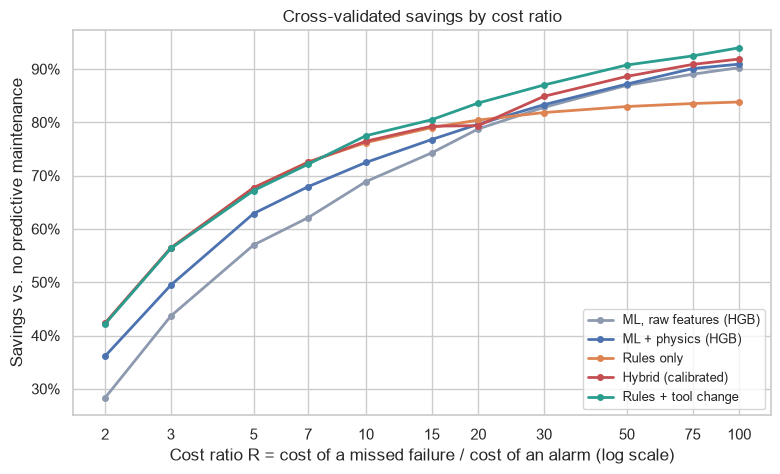

In [5]:
ratios = [2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100]
sensitivity = pd.concat({R: evaluate_policies(R) for R in ratios}, names=["R", "policy"])
savings = sensitivity["savings"].unstack("policy")[list(POLICY_COLORS)]

fig, ax = plt.subplots(figsize=(9, 5))
for name in POLICY_COLORS:
    ax.plot(
        savings.index, savings[name], marker="o", ms=4, lw=2, color=POLICY_COLORS[name], label=name
    )
ax.set_xscale("log")
ax.set_xticks(ratios, [str(r) for r in ratios])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Cost ratio R = cost of a missed failure / cost of an alarm (log scale)")
ax.set_ylabel("Savings vs. no predictive maintenance")
ax.set_title("Cross-validated savings by cost ratio")
ax.legend(loc="lower right", fontsize=9)
save(fig, "sensitivity")
plt.show()

In [6]:
summary = pd.DataFrame(
    {
        "best policy": sensitivity["cost"].unstack("policy").idxmin(axis=1),
        # A threshold at RULE_SCORE means "alarm on rules only", i.e. never change tools early
        "tool change at (min)": sensitivity.xs("Rules + tool change", level="policy")[
            "threshold (median)"
        ].where(lambda t: t < RULE_SCORE),
        "rules + tool change savings": savings["Rules + tool change"],
        "hybrid savings": savings["Hybrid (calibrated)"],
        "rules only savings": savings["Rules only"],
    }
)
summary.style.format(
    {
        "tool change at (min)": "{:.0f}",
        "rules + tool change savings": "{:.1%}",
        "hybrid savings": "{:.1%}",
        "rules only savings": "{:.1%}",
    },
    na_rep="never",
)

,best policy,tool change at (min),rules + tool change savings,hybrid savings,rules only savings
R,,,,,
2,Rules only,never,42.2%,42.3%,42.3%
3,Rules only,246,56.3%,56.4%,56.4%
5,Rules only,246,67.2%,67.7%,67.7%
7,Rules only,232,72.1%,72.5%,72.6%
10,Rules + tool change,225,77.5%,76.5%,76.2%
15,Rules + tool change,214,80.5%,79.3%,79.0%
20,Rules + tool change,205,83.6%,79.4%,80.4%
30,Rules + tool change,203,87.0%,84.9%,81.8%
50,Rules + tool change,203,90.8%,88.6%,83.0%


- **Cheap failures (R ≤ 7):** the rules alone are optimal. A tool change is only worth it very late
  (or never), so it adds nothing.
- **R ≥ 10:** rules + tool change wins, and its lead grows with R. As failures get more expensive,
  the optimal tool change moves earlier, from about 225 minutes towards 200.
- **The rules alone fall behind for expensive failures**, because they never catch tool wear failures.
  At R = 100 they save about 84%, while rules + tool change saves about 94%.
- **The hybrid ML model never beats the simpler policies**, even though it has the best PR-AUC. It
  ties with the rules for cheap failures and falls behind rules + tool change for expensive ones.

The best policy depends on the business context. A single metric like F1 or PR-AUC cannot tell you
which one to deploy.

## 5. Why the simple policy beats the ML model for tool wear failures

Both policies agree on the rule failures. The difference is how they rank the **remaining rows**,
where the only catchable failures are tool wear failures. The plot below shows how many tool wear
failures each score catches as more of these rows raise an alarm:

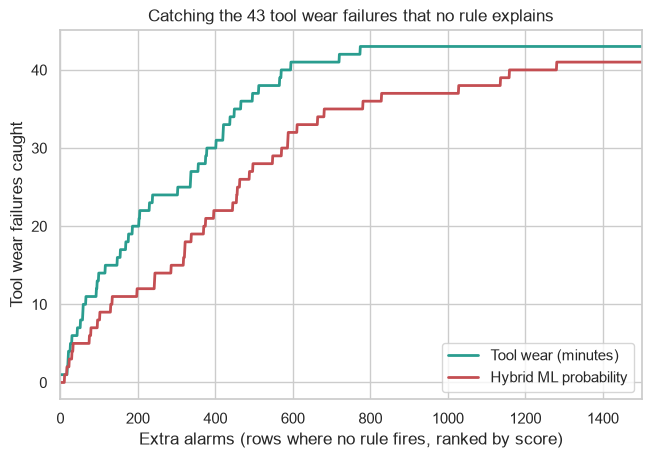

In [7]:
no_rule = ~rule_flags(X).any(axis=1).to_numpy()
twf = (df["twf"] == 1).to_numpy() & (y == 1).to_numpy() & no_rule

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for name, label in [
    ("Rules + tool change", "Tool wear (minutes)"),
    ("Hybrid (calibrated)", "Hybrid ML probability"),
]:
    s = scores[name][no_rule]
    order = np.argsort(-s, kind="stable")
    caught = np.cumsum(twf[no_rule][order])
    ax.plot(np.arange(1, len(s) + 1), caught, lw=2, color=POLICY_COLORS[name], label=label)
ax.set_xlim(0, 1500)
ax.set_xlabel("Extra alarms (rows where no rule fires, ranked by score)")
ax.set_ylabel("Tool wear failures caught")
ax.set_title(f"Catching the {twf.sum()} tool wear failures that no rule explains")
ax.legend(loc="lower right")
save(fig, "tool_wear_capture")
plt.show()

Ranking by **tool wear alone** catches tool wear failures much faster than the ML probability.

The ML model sees the 43 tool wear failures as isolated points among hundreds of similar
non-failures. It partly learns their *noise*: specific combinations of speed, torque and temperature
that happened to occur with a failure, but carry no real signal. Tool wear, on the other hand, is
monotone in risk, because an older tool is always more likely to be close to its random failure time.
When the only real signal is "how old is the tool", the simplest score is the best.

## 6. Calibration: can the probabilities be trusted?

The decision thresholds above are chosen empirically, so they work even with poorly calibrated
probabilities. The demo app, however, will show a **failure probability** to the user, and that
number should mean what it says: of all processes shown with 5% risk, about 5% should fail.

We compare three versions of the hybrid:

| Variant | ML part trained on | Calibration |
|---|---|---|
| All rows, uncalibrated | all rows | none (the M4 hybrid) |
| All rows, calibrated | all rows | isotonic |
| **Rows without a rule, calibrated** | only rows where no rule fires | isotonic (`hybrid_model()`, used above) |

In [8]:
all_rows_calibrated = RulesThenModel(
    CalibratedClassifierCV(
        make_pipeline(HistGradientBoostingClassifier(random_state=0), physics=True),
        method="isotonic",
        cv=5,
    )
)
variants = {
    "All rows, uncalibrated": oof["Hybrid: rules + HGB (physics)"].to_numpy(),
    "All rows, calibrated": oof_proba(all_rows_calibrated, X, y, make_cv()),
    "Rows without a rule, calibrated": scores["Hybrid (calibrated)"],
}
VARIANT_COLORS = dict(zip(variants, ["#8d99ae", "#dd8452", "#c44e52"], strict=True))

pd.DataFrame(
    {
        name: {
            "PR-AUC": average_precision_score(y, p),
            "Brier score": brier_score_loss(y, p),
            "log loss": log_loss(y, np.clip(p, 1e-6, 1 - 1e-6)),
        }
        for name, p in variants.items()
    }
).T.style.format("{:.4f}")

,PR-AUC,Brier score,log loss
"All rows, uncalibrated",0.9053,0.0065,0.0389
"All rows, calibrated",0.9045,0.0058,0.0291
"Rows without a rule, calibrated",0.9134,0.0050,0.0266


In [9]:
no_rule = ~rule_flags(X).any(axis=1).to_numpy()
BINS = (0, 0.002, 0.01, 0.05, 0.2, 0.5, 1.0)


def reliability(p):
    # Predicted vs. observed failure rate for rows where no rule fires
    p, target = pd.Series(p[no_rule]), pd.Series(y.to_numpy()[no_rule])
    b = pd.cut(p, BINS, right=False)
    return pd.DataFrame(
        {
            "rows": p.groupby(b, observed=True).size(),
            "predicted": p.groupby(b, observed=True).mean(),
            "observed": target.groupby(b, observed=True).mean(),
        }
    )


rel = pd.concat({name: reliability(p) for name, p in variants.items()}, axis=1)
rel.index.name = "predicted probability"
rel.style.format("{:.3f}", na_rep="–").format(
    "{:.0f}", subset=[(name, "rows") for name in variants], na_rep="–"
)

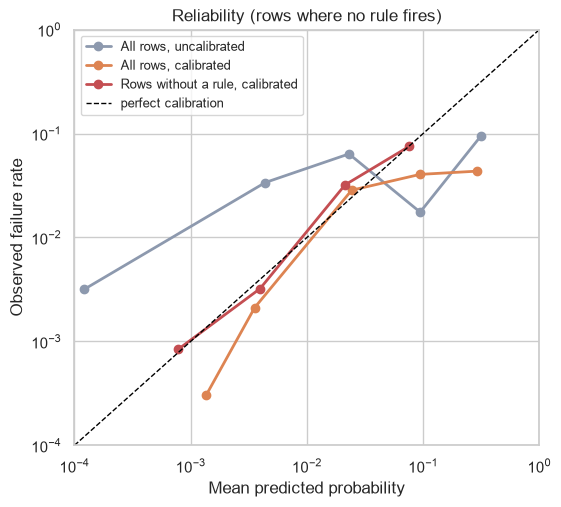

In [10]:
fig, ax = plt.subplots(figsize=(6, 5.4))
for name, p in variants.items():
    r = reliability(p)
    r = r[r["observed"] > 0]
    ax.plot(r["predicted"], r["observed"], marker="o", lw=2, color=VARIANT_COLORS[name], label=name)
ax.plot([1e-4, 1], [1e-4, 1], color="black", ls="--", lw=1, label="perfect calibration")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-4, 1)
ax.set_ylim(1e-4, 1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed failure rate")
ax.set_title("Reliability (rows where no rule fires)")
ax.legend(loc="upper left", fontsize=9)
save(fig, "calibration")
plt.show()

Rows where a rule fires always get probability 1 and are always failures, so the table and plot
only show the rest. Points with no observed failures cannot be drawn on a log scale.

- **All rows, uncalibrated:** overconfident at both ends. Rows predicted at almost 0% fail
  noticeably often, and rows predicted at 30–80% rarely fail.
- **All rows, calibrated:** calibration fixes the low end, but rows predicted at about 30% still fail
  only about 4% of the time. **Calibration alone was not enough.**
- **Rows without a rule, calibrated:** predicted and observed rates agree closely in every bin with
  enough rows (the top bin holds a single row). This version also has the best Brier score, log loss
  and PR-AUC.

**Why training on the right rows matters:** in the hybrid, the ML model is only ever asked about rows
where no rule fires. If it is trained (and calibrated) on all rows, it learns that a high score
usually means a failure, because most high-scoring rows are rule failures. Among the rows it
actually sees, a high score is much less reliable. Training and calibrating on the population the
model will actually be used on removes this mismatch.

With calibrated probabilities, decision theory gives the threshold directly. An alarm is worth it
when the expected cost of waiting is higher than the cost of the alarm, `p · R > 1`, so the
threshold is **p > 1/R**. This needs no tuning at all:

In [11]:
rows = []
for R in [5, 10, 20, 50, 100]:
    row = {"R": R, "threshold 1/R": 1 / R}
    for name, p in variants.items():
        row[f"1/R: {name}"] = policy_cost(y, p > 1 / R, R)["cost"]
    row["CV-tuned: rows without a rule, calibrated"] = cv_policy_cost(
        y, variants["Rows without a rule, calibrated"], R, splits
    )["cost"]
    rows.append(row)
thresholds_1r = pd.DataFrame(rows).set_index("R")
thresholds_1r.style.format("{:,.0f}").format("{:.3f}", subset=["threshold 1/R"])

,threshold 1/R,"1/R: All rows, uncalibrated","1/R: All rows, calibrated","1/R: Rows without a rule, calibrated","CV-tuned: rows without a rule, calibrated"
R,,,,,
5,0.200,578,590,548,547
10,0.100,849,901,798,798
20,0.050,"1,365","1,406","1,254","1,398"
50,0.020,"2,656","2,095","2,032","1,929"
100,0.010,"4,441","2,728","2,676","2,752"


With the final hybrid, the untuned `1/R` threshold stays within about 5% of the cross-validated
threshold, and is even better for R = 20 and R = 100. With the poorly calibrated variants, `1/R` is
noticeably worse, especially for expensive failures (up to 66% more cost at R = 100).

The app (M7) therefore needs only **one slider for R**, and derives the alarm threshold as 1/R.

## 7. Save results

In [12]:
out = sensitivity.reset_index()
out.to_csv(REPORTS_DIR / "05_policy_costs.csv", index=False, float_format="%.4f")
print(
    "Saved: 05_policy_costs.csv",
    f"({len(out)} rows: {len(ratios)} cost ratios × {len(scores) + 1} policies)",
)

Saved: 05_policy_costs.csv (66 rows: 11 cost ratios × 6 policies)


## 8. Recommendation

| Situation | Recommended policy |
|---|---|
| Failures are cheap (R ≤ 5) | Physics rules only |
| Default (R ≈ 10) | Physics rules + change tools at about **225 minutes** |
| Failures are expensive (R ≥ 20) | Physics rules + change tools at about **200–205 minutes** |
| Showing a risk score to operators | Calibrated hybrid probability, alarm if p > 1/R |

**In business terms (R = 10):** compared with running to failure, the recommended policy avoids
about 77% of the maintenance cost. Every alarm from the physics rules is a real failure, and the
extra alarms from tool changes are planned stops instead of breakdowns.

**Limitations:**

- **Static evaluation.** In reality, replacing tools at 225 minutes means that no process would ever
  run with an older tool, so the data after deployment would look different. The estimate shows the
  direction and size of the benefit, not an exact number.
- **One alarm cost.** An inspection and a tool change are treated as equally expensive. If a tool
  change costs more, W moves later. The cost functions in `src/pdm/cost.py` take any alarm cost.
- **R is an assumption.** It should come from the plant's own downtime and repair costs. Section 4
  shows that the recommendation is stable for any R of 10 or more.

**Next (M6):** a training script that builds the final model and writes metrics, unit tests in CI,
and a clean package for the demo app.